## Resources

In [24]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt

import joblib
import os

## Load Data

In [25]:
train_df = pd.read_parquet(
"/content/drive/MyDrive/Mule Account Detection and Classification/data/train.parquet"
)

valid_df = pd.read_parquet(
"/content/drive/MyDrive/Mule Account Detection and Classification/data/validation.parquet"
)

test_df = pd.read_parquet(
"/content/drive/MyDrive/Mule Account Detection and Classification/data/test.parquet"
)

## Feature Selection

In [26]:
TARGET = "F3924"

X_train = train_df.drop(
    columns=[TARGET]
)

X_valid = valid_df.drop(
    columns=[TARGET]
)

X_test = test_df.drop(
    columns=[TARGET]
)

y_valid = valid_df[TARGET]

y_test = test_df[TARGET]

## Train Isolation Forest

In [27]:
iso_model = IsolationForest(

    n_estimators=500,

    contamination=0.01,

    max_samples="auto",

    random_state=42,

    n_jobs=-1
)

## Generate Anomaly Scores

In [28]:
iso_model.fit(X_train)

IsolationForest(contamination=0.01, n_estimators=500, n_jobs=-1,
                random_state=42)

## Validation Evaluation

In [29]:
valid_scores = -iso_model.score_samples(
    X_valid
)

test_scores = -iso_model.score_samples(
    X_test
)

# Higher scores = More suspicious

## Test Evaluation

In [30]:
thresholds = np.percentile(
    valid_scores,
    np.arange(80,100)
)

## Confusion Matrix

In [31]:
results = []

for threshold in thresholds:

    preds = (
        valid_scores >= threshold
    ).astype(int)

    results.append({

        "threshold":
        threshold,

        "precision":
        precision_score(
            y_valid,
            preds,
            zero_division=0
        ),

        "recall":
        recall_score(
            y_valid,
            preds,
            zero_division=0
        ),

        "f1":
        f1_score(
            y_valid,
            preds,
            zero_division=0
        )
    })

results_df = pd.DataFrame(
    results
)

results_df

,threshold,precision,recall,f1
0,0.418054,0.0,0.0,0.0
1,0.420011,0.0,0.0,0.0
2,0.420771,0.0,0.0,0.0
3,0.422140,0.0,0.0,0.0
4,0.423193,0.0,0.0,0.0
5,0.424676,0.0,0.0,0.0
6,0.425889,0.0,0.0,0.0
7,0.427159,0.0,0.0,0.0
8,0.428234,0.0,0.0,0.0
9,0.429139,0.0,0.0,0.0


## Classification Report

In [32]:
best_row = results_df.loc[
    results_df["f1"].idxmax()
]

best_row

,0
threshold,0.418054
precision,0.000000
recall,0.000000
f1,0.000000


## ROC Curve

In [33]:
best_threshold = best_row[
    "threshold"
]

test_pred = (
    test_scores >= best_threshold
).astype(int)

## PR Curve

In [34]:
iso_metrics = {

    "Accuracy":
    accuracy_score(
        y_test,
        test_pred
    ),

    "Precision":
    precision_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "Recall":
    recall_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "F1":
    f1_score(
        y_test,
        test_pred,
        zero_division=0
    ),

    "ROC_AUC":
    roc_auc_score(
        y_test,
        test_scores
    )
}

iso_metrics

{'Accuracy': 0.7747615553925165,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC_AUC': np.float64(0.19183320996792497)}

## Gain Chart

In [35]:
cm = confusion_matrix(
    y_test,
    test_pred
)

cm_df = pd.DataFrame(
    cm
)

cm_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"isolation_forest_confusion_matrix.csv"
)

cm_df

,0,1
0,1056,295
1,12,0


## Lift Chart

In [36]:
report = classification_report(
    y_test,
    test_pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"isolation_forest_classification_report.csv"
)

report_df

,precision,recall,f1-score,support
0,0.988764,0.781643,0.873088,1351.000000
1,0.000000,0.000000,0.000000,12.000000
accuracy,0.774762,0.774762,0.774762,0.774762
macro avg,0.494382,0.390822,0.436544,1363.000000
weighted avg,0.980059,0.774762,0.865401,1363.000000


## Score Distribution

In [37]:
fpr,tpr,_ = roc_curve(
    y_test,
    test_scores
)

roc_df = pd.DataFrame({

    "fpr":fpr,
    "tpr":tpr
})

roc_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"isolation_forest_roc_curve.csv",

index=False
)

## Feature Contribution Analysis

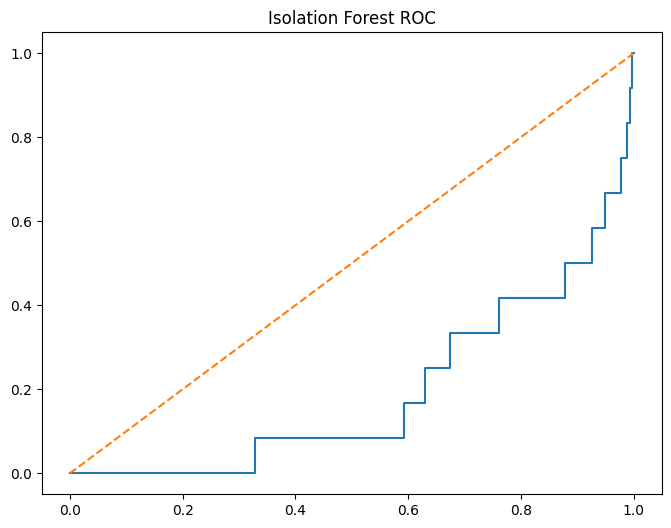

In [38]:
plt.figure(figsize=(8,6))

plt.plot(fpr,tpr)

plt.plot([0,1],[0,1],"--")

plt.title(
    "Isolation Forest ROC"
)

plt.savefig(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"isolation_forest_roc_curve.png",

dpi=300
)

plt.show()

## Save Reports

In [39]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_scores
)

pr_df = pd.DataFrame({

    "precision":precision[:-1],
    "recall":recall[:-1],
    "threshold":thresholds
})

pr_df.to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"isolation_forest_pr_curve.csv",

index=False
)

## Save Model

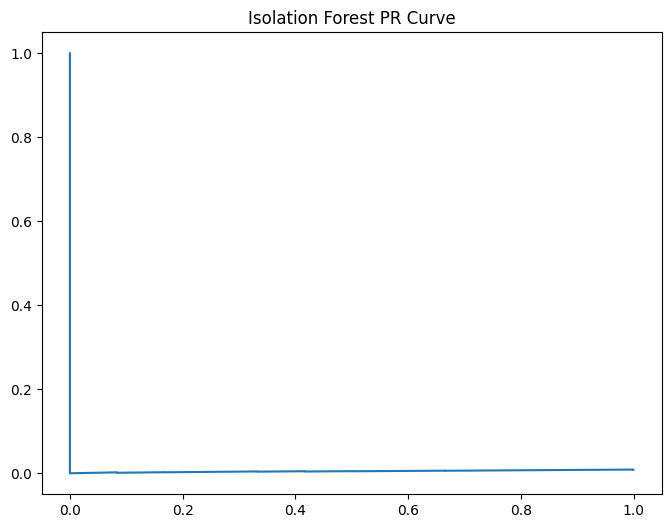

In [40]:
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.title(
    "Isolation Forest PR Curve"
)

plt.savefig(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"isolation_forest_pr_curve.png",

dpi=300
)

plt.show()

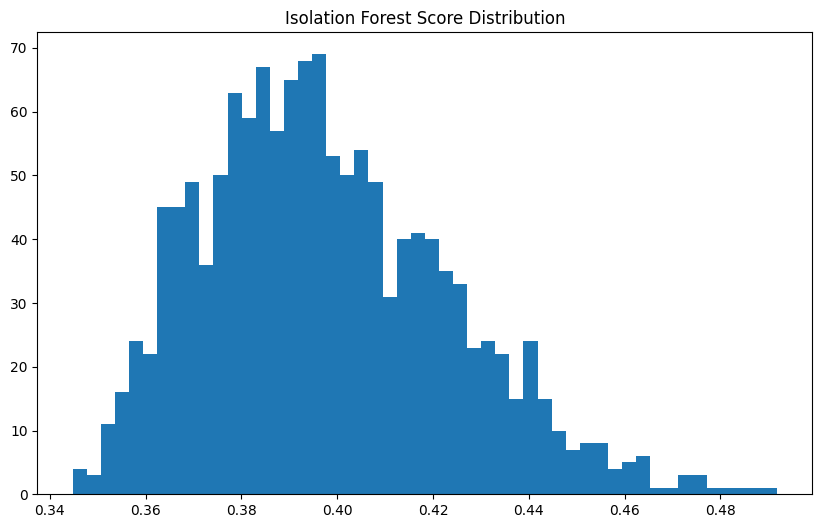

In [41]:
plt.figure(figsize=(10,6))

plt.hist(
    test_scores,
    bins=50
)

plt.title(
    "Isolation Forest Score Distribution"
)

plt.savefig(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"isolation_forest_score_distribution.png",

dpi=300
)

plt.show()

In [42]:
pd.DataFrame(
    [iso_metrics]
).to_csv(

"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"reports/"
"isolation_forest_metrics.csv",

index=False
)

In [43]:
MODEL_DIR = (
"/content/drive/MyDrive/"
"Mule Account Detection and Classification/"
"models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

joblib.dump(

    iso_model,

    MODEL_DIR +
    "/isolation_forest.pkl"
)

['/content/drive/MyDrive/Mule Account Detection and Classification/models/isolation_forest.pkl']

## Deliverables

isolation_forest.pkl

isolation_forest_metrics.csv

isolation_forest_confusion_matrix.csv

isolation_forest_classification_report.csv

isolation_forest_roc_curve.csv

isolation_forest_pr_curve.csv

isolation_forest_roc_curve.png

isolation_forest_pr_curve.png

isolation_forest_score_distribution.png